In [9]:
import numpy as np

A = np.random.random((50, 50))
b = np.random.random((50,1))

U, s, Vt = np.linalg.svd(A)

x = Vt.T @ np.diag(1/s) @ U.T @ b

x_s = np.linalg.solve(A, b)
np.allclose(x, x_s)

Ainv = np.linalg.inv(A)
Ainv2 = Vt.T @ np.diag(1/s) @ U.T
print(np.allclose(Ainv, Ainv2))

True


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


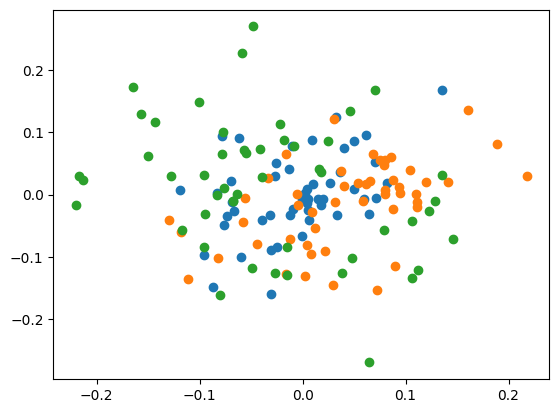

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
# print(iris.data.shape)
print(iris.target)

target0_idx = np.where(iris.target==0)[0]
target1_idx = np.where(iris.target==1)[0]
target2_idx = np.where(iris.target==2)[0]

U, s, Vt = np.linalg.svd(iris.data, full_matrices=False)
# print(U.shape)
# print(s)
# print(Vt.shape)
# plt.scatter(U[:,0], U[:,1])

plt.scatter(U[target0_idx, 2], U[target0_idx, 3])
plt.scatter(U[target1_idx, 2], U[target1_idx, 3])
plt.scatter(U[target2_idx, 2], U[target2_idx, 3])

plt.show()

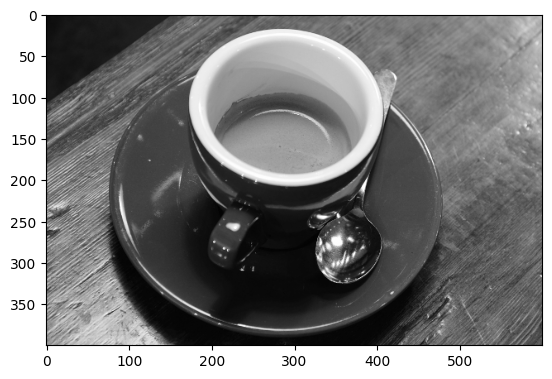

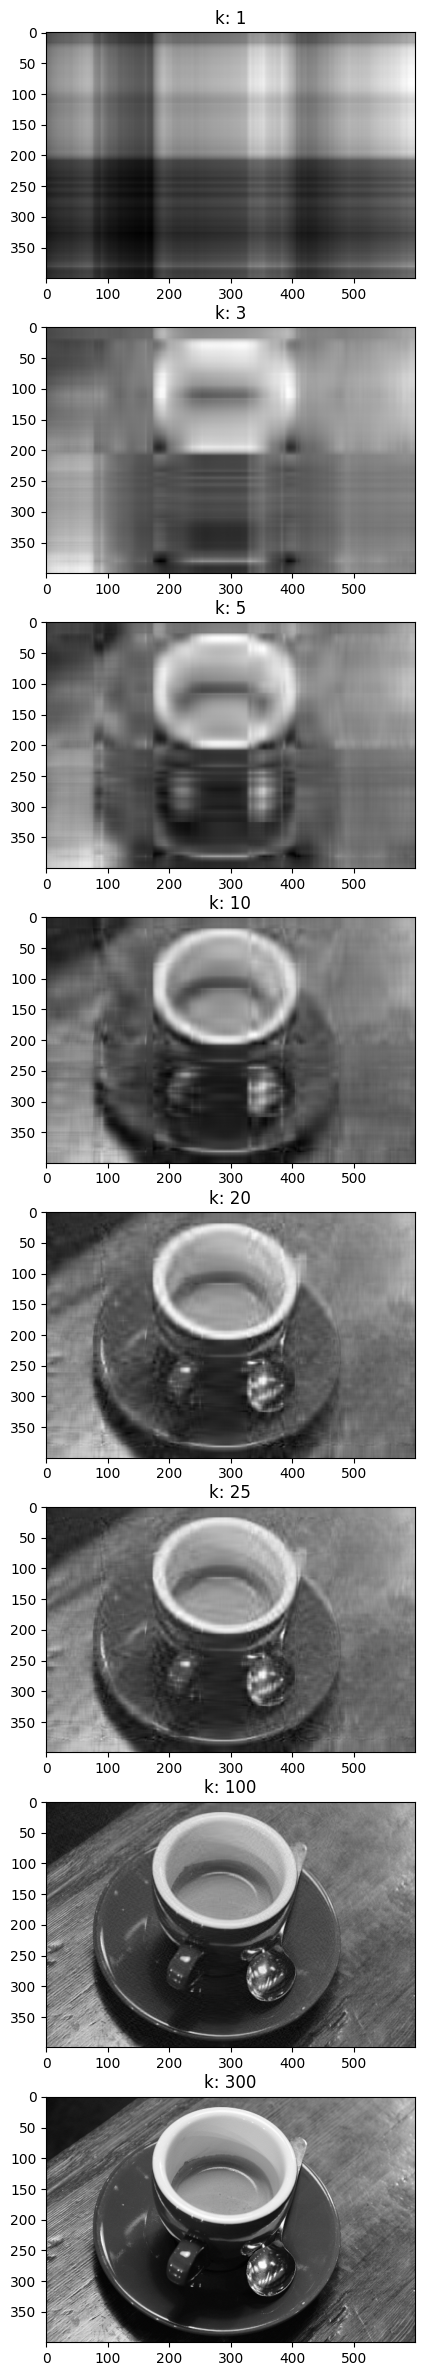

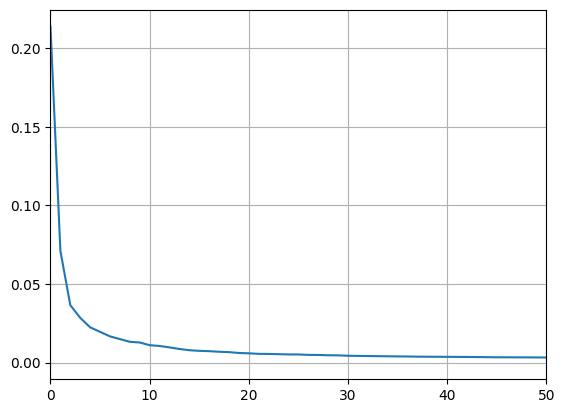

In [18]:
from skimage.color import rgb2gray
from skimage import data
import matplotlib.pyplot as plt
import numpy as np

coffee = data.coffee()
gray_coffee = rgb2gray(coffee)

plt.figure()
plt.imshow(gray_coffee, cmap='gray')
plt.show()

U, s, V_T = np.linalg.svd(gray_coffee, full_matrices=False)

S = np.diag(s)

fig, axs = plt.subplots(8, figsize=(10, 30))
i = 0
for k in [1, 3, 5, 10, 20, 25, 100, 300]:
    constructed_coffee = U[:, :k] @ S[:k, :k] @ V_T[:k, :]
    axs[i].imshow(constructed_coffee, cmap='gray')
    axs[i].set_title('k: ' + str(k))
    i += 1
    
plt.show()

s = s / np.sum(s)

x = np.arange(s.shape[0])
plt.figure()
plt.plot(x, s)
plt.xlim(0, 50)
plt.grid()
plt.show()